# Vehicle Insurance Fraud Detection 

## Executive Summary

Insurance fraud costs the industry billions annually, resulting in increased premiums for honest customers. This project develops an automated fraud detection system using machine learning by building a classification model to identify potentially fraudulent insurance claims with high accuracy while minimizing false positives.
 

---
<a id='1'></a>
## 1. `Environment Setup and Data Loading`

Import required libraries and load the vehicle insurance claims dataset for analysis and load dataset and display basic information 

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, validation_curve, RandomizedSearchCV, cross_val_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif, SelectFromModel
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             f1_score, precision_score, recall_score, roc_auc_score,
                             precision_recall_curve, roc_curve)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import warnings
import json
from datetime import datetime

# Configure display and warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

print(" All libraries imported successfully")


 All libraries imported successfully


In [2]:
# Load the dataset
df = pd.read_csv('vehicledata.csv')

# Display basic information
print("DATASET OVERVIEW")
print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("FIRST 5 RECORDS")
display(df.head())
print("DATA TYPES")
print(df.dtypes)
print("TARGET VARIABLE DISTRIBUTION")

fraud_counts = df['FraudFound_P'].value_counts()
fraud_pct = df['FraudFound_P'].value_counts(normalize=True) * 100

print(f"\nFraud Cases (1): {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)")
print(f"Legitimate Cases (0): {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)")
print(f"\nClass Imbalance Ratio: 1:{fraud_counts[0]/fraud_counts[1]:.1f}")


DATASET OVERVIEW

Dataset Shape: 15,420 rows × 33 columns

Memory Usage: 21.03 MB
FIRST 5 RECORDS


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


DATA TYPES
Month                     str
WeekOfMonth             int64
DayOfWeek                 str
Make                      str
AccidentArea              str
DayOfWeekClaimed          str
MonthClaimed              str
WeekOfMonthClaimed      int64
Sex                       str
MaritalStatus             str
Age                     int64
Fault                     str
PolicyType                str
VehicleCategory           str
VehiclePrice              str
FraudFound_P            int64
PolicyNumber            int64
RepNumber               int64
Deductible              int64
DriverRating            int64
Days_Policy_Accident      str
Days_Policy_Claim         str
PastNumberOfClaims        str
AgeOfVehicle              str
AgeOfPolicyHolder         str
PoliceReportFiled         str
WitnessPresent            str
AgentType                 str
NumberOfSuppliments       str
AddressChange_Claim       str
NumberOfCars              str
Year                    int64
BasePolicy                str

When you look at class imbalance, it is astronomical, therefore we will use F1 score and the evaluation metric across the project

### a. Data Dictionary



The target variablle is FraudFound_P, whic is a binary indicator where 1 = Fraud detected and  0 = Legitimate claim

#### Temporal Features
- **Month, WeekOfMonth, DayOfWeek** - When the accident occurred
- **MonthClaimed, WeekOfMonthClaimed, DayOfWeekClaimed** - When the claim was filed
- **Days_Policy_Accident** - Time between policy start and accident
- **Days_Policy_Claim** - Time between policy start and claim filing
- **Year** - Year of the claim

#### Policyholder Demographics
- **Age** - Exact age of policyholder
- **AgeOfPolicyHolder** - Age group category
- **Sex** - Gender 
- **MaritalStatus** - Single, Married, Divorced, Widow

#### Vehicle Information
- **Make** - Vehicle manufacturer 
- **VehicleCategory** - Type of vehicle 
- **VehiclePrice** - Price range of the vehicle
- **AgeOfVehicle** - How old the vehicle is

#### Policy Details
- **PolicyType** - Type of insurance policy
- **BasePolicy** - Basic policy type 
- **Deductible** - Amount policyholder pays before insurance coverage
- **PolicyNumber** - Unique policy identifier

#### Claim Characteristics
- **AccidentArea** - Urban vs Rural
- **Fault** - Who was at fault 
- **PoliceReportFiled** - Whether police were involved
- **WitnessPresent** - Whether there were witnesses
- **NumberOfSuppliments** - Additional documentation submitted
- **PastNumberOfClaims** - Claimant's claim history

#### Agent and Administrative
- **AgentType** - Internal vs External insurance agent
- **RepNumber** - Representative ID
- **AddressChange_Claim** - Recent address changes
- **NumberOfCars** - Vehicles owned by policyholder
- **DriverRating** - Driver quality rating 

---

## 2. `Data Quality Assessment`

> Data Cleaning

This is to verify data integrity by checking for missing values, duplicates, and outliers that could impact model performance and to clean it ready for analysis

### Quality Checks Performed
1. Missing Values - Identify incomplete records
2. Duplicate Records - Find identical rows
3. Outlier Detection - Use IQR method for numerical features



In [3]:
# Check for missing values

print("MISSING VALUE ANALYSIS")
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Percentage': missing_pct
})
missing_with_values = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
if len(missing_with_values) > 0:
    print("\nColumns with missing values:")
    print(missing_with_values)
else:
    print("\nNo missing values found in any column")

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

MISSING VALUE ANALYSIS

No missing values found in any column

Total missing values: 0


In [4]:
# Check for duplicate records
print("DUPLICATE RECORDS ANALYSIS")
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicate_count}")
if duplicate_count > 0:
    print(f"Percentage of dataset: {(duplicate_count/len(df))*100:.2f}%")
    print("\n Action needed: Review and remove duplicates")
else:
    print("\n No duplicate records found")

DUPLICATE RECORDS ANALYSIS

Duplicate rows found: 0

 No duplicate records found


In [5]:
# Outlier detection using IQR method
print("OUTLIER DETECTION (IQR Method)")
# Select numerical columns 
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = [col for col in numerical_cols if col not in ['FraudFound_P', 'PolicyNumber']]
outlier_summary = []
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if len(outliers) > 0:
        outlier_summary.append({
            'Column': col,
            'Outlier_Count': len(outliers),
            'Percentage': round(len(outliers)/len(df)*100, 2),
            'Lower_Bound': round(lower_bound, 2),
            'Upper_Bound': round(upper_bound, 2)
        })
if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Count', ascending=False)
    print(outlier_df.to_string(index=False))
else:
    print("No outliers detected in numerical columns")




OUTLIER DETECTION (IQR Method)
    Column  Outlier_Count  Percentage  Lower_Bound  Upper_Bound
Deductible            582        3.77        400.0        400.0
       Age            547        3.55          5.5         73.5


Yes there were outliers, but we chose to keep all of them because sometimes they act as fraud signals.

In [6]:
# Summary statistics
print("SUMMARY STATISTICS - NUMERICAL FEATURES")
display(df.describe().round(2))

SUMMARY STATISTICS - NUMERICAL FEATURES


,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.00,15420.00,15420.00,15420.00,15420.00,15420.00,15420.00,15420.00,15420.00
mean,2.79,2.69,39.86,0.06,7710.50,8.48,407.70,2.49,1994.87
std,1.29,1.26,13.49,0.24,4451.51,4.60,43.95,1.12,0.80
min,1.00,1.00,0.00,0.00,1.00,1.00,300.00,1.00,1994.00
25%,2.00,2.00,31.00,0.00,3855.75,5.00,400.00,1.00,1994.00
50%,3.00,3.00,38.00,0.00,7710.50,8.00,400.00,2.00,1995.00
75%,4.00,4.00,48.00,0.00,11565.25,12.00,400.00,3.00,1996.00
max,5.00,5.00,80.00,1.00,15420.00,16.00,700.00,4.00,1996.00


### Data Quality Assessment Results
- There were no missing values
- Outliers were present in Age and Deductibles but retained
- There were no duplicate values

---
<a id='3'></a>
## 3. `Exploratory Data Analysis (EDA)`

The purpose is to understand fraud patterns in the data before engineering features. This guides feature creation and validates domain assumptions.

### a. Analysis Performed
1. **Fraud Rate by Category** - Which categories have higher fraud rates?
2. **Numerical Distribution** - How do fraud/legitimate claims differ?
3. **Correlation Analysis** - Which features relate to fraud?



FRAUD RATE ANALYSIS BY CATEGORICAL FEATURES

Baseline fraud rate: 5.99%
Categories with rate >10% are HIGH RISK



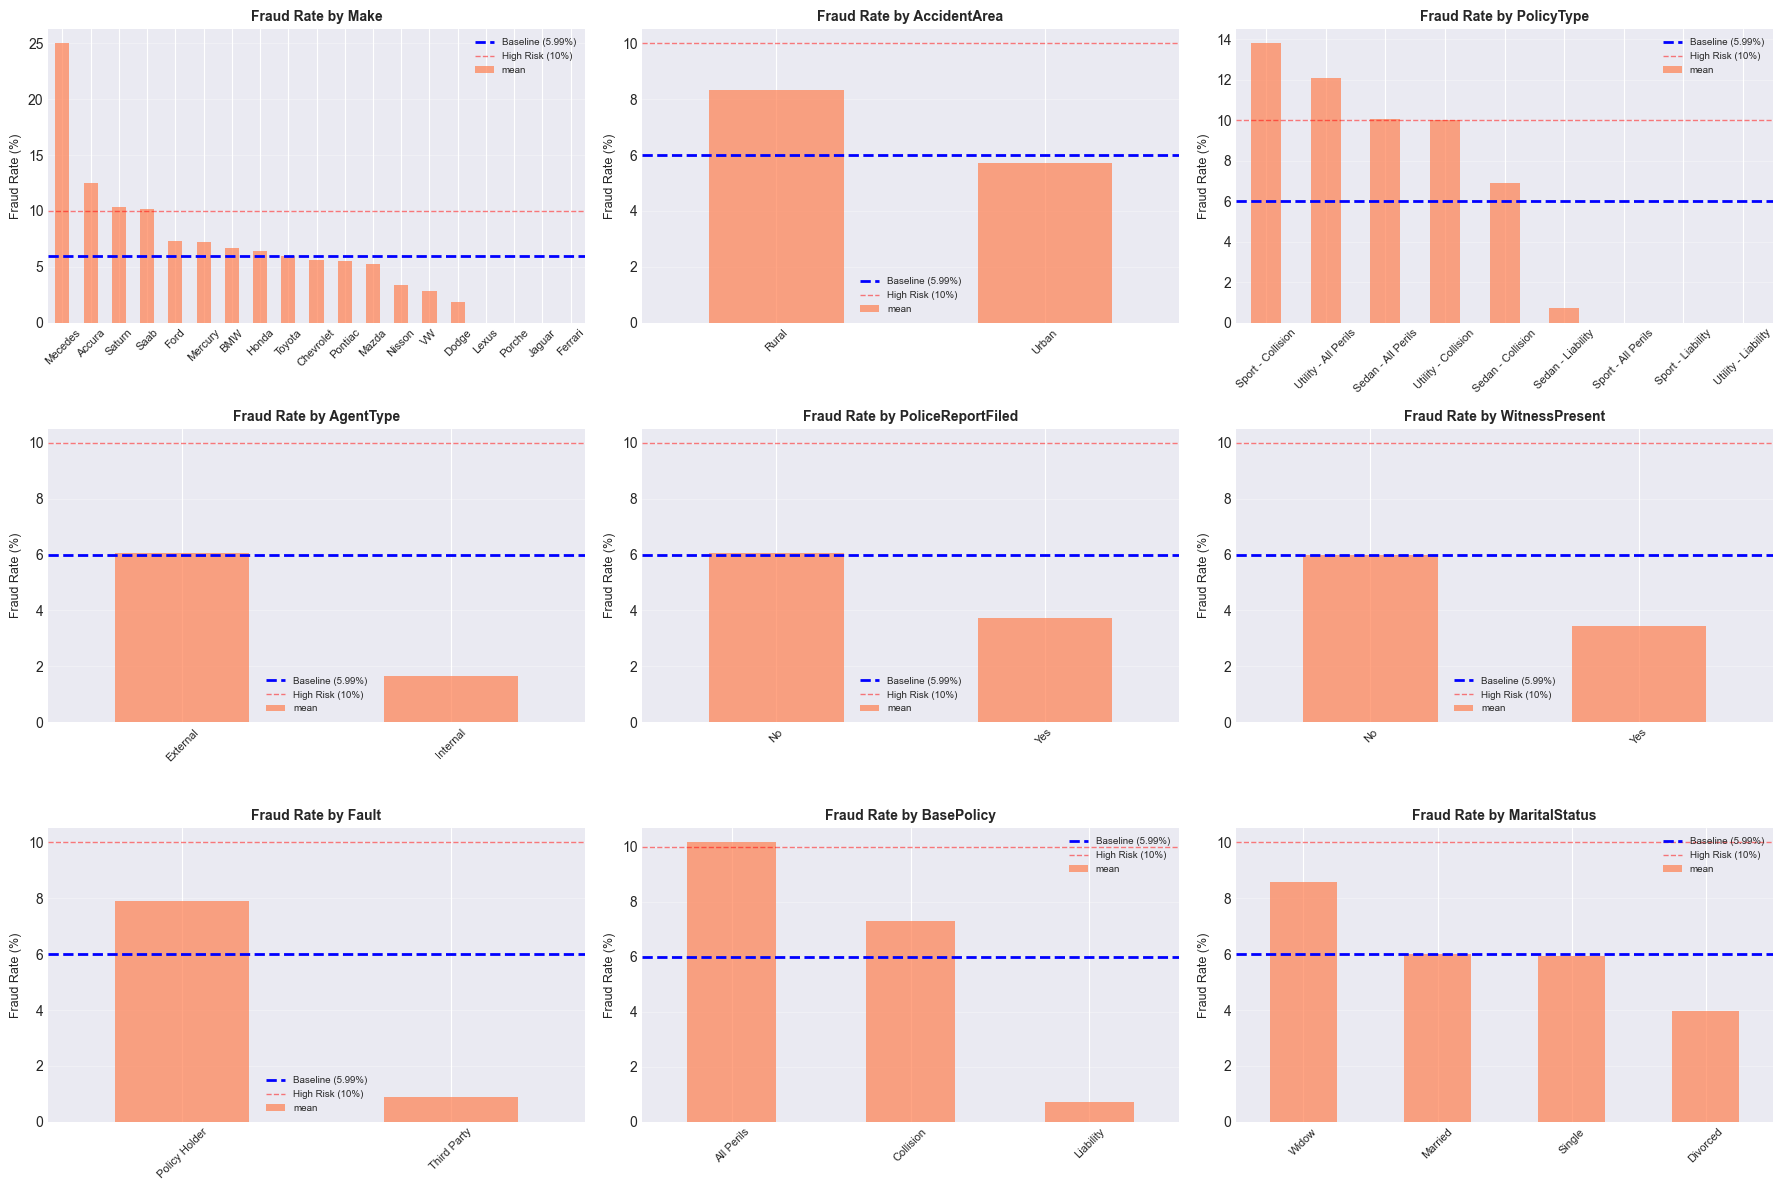

KEY FINDINGS - HIGH RISK CATEGORIES 

Make:
   Mecedes: 25.0% (4 claims)
   Accura: 12.5% (472 claims)
   Saturn: 10.3% (58 claims)
   Saab: 10.2% (108 claims)

PolicyType:
   Sport - Collision: 13.8% (348 claims)
   Utility - All Perils: 12.1% (340 claims)
   Sedan - All Perils: 10.1% (4087 claims)

BasePolicy:
   All Perils: 10.2% (4449 claims)


In [7]:
# Fraud rate by categorical features

print("FRAUD RATE ANALYSIS BY CATEGORICAL FEATURES")
print("\nBaseline fraud rate: 5.99%")
print("Categories with rate >10% are HIGH RISK\n")

categorical_features = ['Make', 'AccidentArea', 'PolicyType', 'AgentType', 
                        'PoliceReportFiled', 'WitnessPresent', 'Fault',
                        'BasePolicy', 'MaritalStatus']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.ravel()
for idx, col in enumerate(categorical_features):
    ax = axes[idx]
    # Calculate fraud rate
    fraud_rate = df.groupby(col)['FraudFound_P'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    fraud_rate['mean'] = fraud_rate['mean'] * 100  # Convert to percentage
    # Plot
    fraud_rate['mean'].plot(kind='bar', ax=ax, color='coral', alpha=0.7)
    ax.axhline(5.99, color='blue', linestyle='--', linewidth=2, label='Baseline (5.99%)')
    ax.axhline(10, color='red', linestyle='--', linewidth=1, alpha=0.5, label='High Risk (10%)')
    ax.set_title(f'Fraud Rate by {col}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Fraud Rate (%)', fontsize=9)
    ax.set_xlabel('')
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fraud_rate_by_category.png', dpi=300, bbox_inches='tight')
plt.show()
# Print top findings
print("KEY FINDINGS - HIGH RISK CATEGORIES ")
for col in categorical_features:
    fraud_rate = df.groupby(col)['FraudFound_P'].mean() * 100
    high_risk = fraud_rate[fraud_rate > 10].sort_values(ascending=False)
    
    if len(high_risk) > 0:
        print(f"\n{col}:")
        for category, rate in high_risk.items():
            count = len(df[df[col] == category])
            print(f"   {category}: {rate:.1f}% ({count} claims)")

NUMERICAL FEATURE DISTRIBUTIONS - FRAUD vs LEGITIMATE


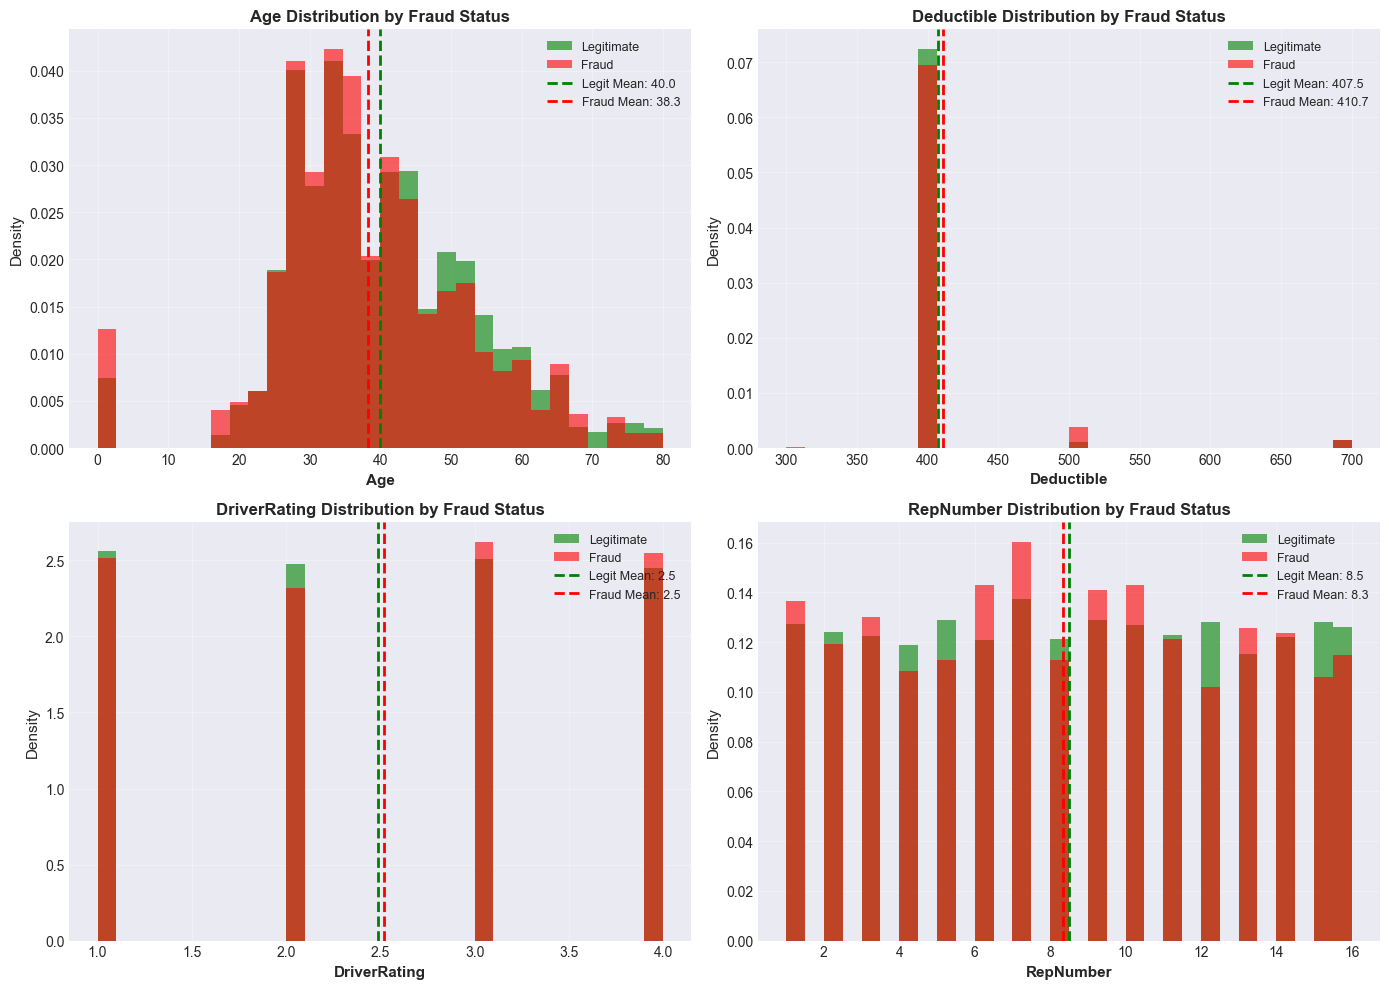

STATISTICAL COMPARISON - FRAUD vs LEGITIMATE

Age:
  Fraud Mean: 38.27
  Legitimate Mean: 39.96
  Difference: -4.2%

Deductible:
  Fraud Mean: 410.73
  Legitimate Mean: 407.51
  Difference: +0.8%

DriverRating:
  Fraud Mean: 2.52
  Legitimate Mean: 2.49
  Difference: +1.4%

RepNumber:
  Fraud Mean: 8.35
  Legitimate Mean: 8.49
  Difference: -1.7%


In [8]:
# Numerical features: Fraud vs Legitimate distribution

print("NUMERICAL FEATURE DISTRIBUTIONS - FRAUD vs LEGITIMATE")
numerical_features_viz = ['Age', 'Deductible', 'DriverRating', 'RepNumber']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for idx, col in enumerate(numerical_features_viz):
    ax = axes[idx]
    # Separate fraud and legitimate
    fraud_data = df[df['FraudFound_P'] == 1][col]
    legit_data = df[df['FraudFound_P'] == 0][col]
    # Plot histograms
    ax.hist(legit_data, bins=30, alpha=0.6, label='Legitimate', color='green', density=True)
    ax.hist(fraud_data, bins=30, alpha=0.6, label='Fraud', color='red', density=True)
    # Add mean lines
    ax.axvline(legit_data.mean(), color='green', linestyle='--', linewidth=2, 
               label=f'Legit Mean: {legit_data.mean():.1f}')
    ax.axvline(fraud_data.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Fraud Mean: {fraud_data.mean():.1f}')
    ax.set_xlabel(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{col} Distribution by Fraud Status', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('numerical_distributions_fraud_vs_legit.png', dpi=300, bbox_inches='tight')
plt.show()
# Statistical comparison
print("STATISTICAL COMPARISON - FRAUD vs LEGITIMATE")

for col in numerical_features_viz:
    fraud_mean = df[df['FraudFound_P'] == 1][col].mean()
    legit_mean = df[df['FraudFound_P'] == 0][col].mean()
    diff_pct = ((fraud_mean - legit_mean) / legit_mean) * 100
    print(f"\n{col}:")
    print(f"  Fraud Mean: {fraud_mean:.2f}")
    print(f"  Legitimate Mean: {legit_mean:.2f}")
    print(f"  Difference: {diff_pct:+.1f}%")

FEATURE CORRELATION WITH FRAUD

Higher absolute correlation = stronger relationship with fraud



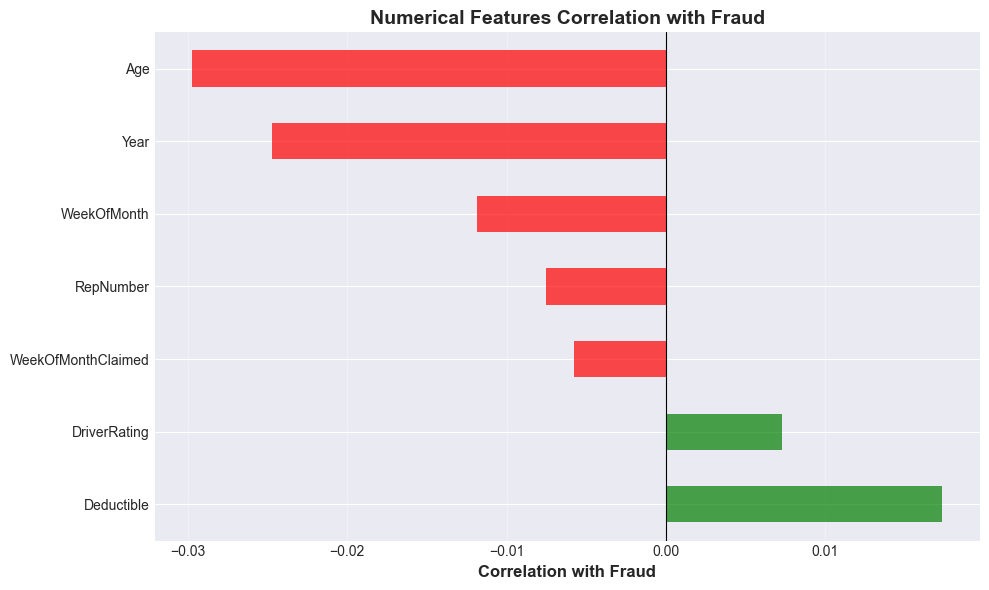


Top Positive Correlations :
Deductible            0.017348
DriverRating          0.007266
WeekOfMonthClaimed   -0.005761
RepNumber            -0.007551
WeekOfMonth          -0.011861
Name: FraudFound_P, dtype: float64

Top Negative Correlations :
WeekOfMonthClaimed   -0.005761
RepNumber            -0.007551
WeekOfMonth          -0.011861
Year                 -0.024760
Age                  -0.029741
Name: FraudFound_P, dtype: float64


In [9]:
# Correlation with fraud
print("FEATURE CORRELATION WITH FRAUD")
print("\nHigher absolute correlation = stronger relationship with fraud\n")

# Calculate correlations for numerical features only
fraud_corr = df[numerical_cols + ['FraudFound_P']].corr()['FraudFound_P'].drop('FraudFound_P').sort_values(ascending=False)

# Visualize
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in fraud_corr]
fraud_corr.plot(kind='barh', color=colors, alpha=0.7)
plt.xlabel('Correlation with Fraud', fontsize=12, fontweight='bold')
plt.title('Numerical Features Correlation with Fraud', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fraud_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop Positive Correlations :")
print(fraud_corr.head(5))
print("\nTop Negative Correlations :")
print(fraud_corr.tail(5))

### b. EDA Insights

**High-Risk Indicators Discovered**:
- External agents show higher fraud rates than internal
- No police report filed equals elevated risk
- No witness present equals higher fraud rate
- Third-party fault claims may have elevated rates

**Protective Factors**:
- Police report filed equals lower fraud rate
- Witness present equals lower fraud rate
- Certain vehicle makes show lower fraud

**Feature Engineering Targets**:
1. Combine external agent and no police report
2. Create risk scores for vehicle type and price combinations
3. Temporal patterns 



---
<a id='4'></a>
## 4. `Feature Engineering`

> Feature Engineering and Extraction

The piprpose for this is to create new features that capture fraud patterns identified in domain expertise and EDA. Good features are the most impactful way to improve model performance.

### Feature Categories
1. **Temporal Indicators** - Time based fraud patterns
2. **Claim Behavior** - How claims are filed and modified
3. **Risk Profiles** - Demographic and vehicle risk combinations
4. **Interaction Features** - Multiple suspicious factors together

Each feature represents a known fraud pattern from insurance domain knowledge. We document WHy each feature matters for transparency and validation.

### a. Temporal Fraud Indicators

fraudsters often exhibit time based patterns that differ from legitimate claimants. Timing can reveal premeditation or staged accidents.

#### Features Created:

**Quick_Claim**
- **Definition** - Claim filed within 15-30 days of policy purchase or immediately
- **Fraud Signal** - Suggests policy bought specifically to file claim 


**Same_Week_Claim**
- **Definition** - Accident and claim occurred in the same week
- **Fraud Signal** - Unusually fast claim filing may indicate coordination/planning


**Weekend_Accident**
- **Definition** - Accident occurred on Saturday or Sunday
- **Fraud Signal** - Staged accidents often happen on weekends 


In [10]:
# Create a copy for feature engineering
df_engineered = df.copy()

print("FEATURE ENGINEERING - TEMPORAL INDICATORS")

# Feature 1: Quick Claim
df_engineered['Quick_Claim'] = df_engineered['Days_Policy_Claim'].apply(
    lambda x: 1 if x in ['15 to 30', 'none'] else 0
)
fraud_rate_quick = df_engineered.groupby('Quick_Claim')['FraudFound_P'].mean() * 100
print(f"\n Quick_Claim created")
print(f"  Fraud rate when Quick_Claim=1: {fraud_rate_quick.get(1, 0):.2f}%")
print(f"  Fraud rate when Quick_Claim=0: {fraud_rate_quick.get(0, 0):.2f}%")

# Feature 2: Same Week Claim
df_engineered['Same_Week_Claim'] = (
    df_engineered['WeekOfMonth'] == df_engineered['WeekOfMonthClaimed']
).astype(int)
fraud_rate_same_week = df_engineered.groupby('Same_Week_Claim')['FraudFound_P'].mean() * 100
print(f"\n Same_Week_Claim created")
print(f"  Fraud rate when Same_Week_Claim=1: {fraud_rate_same_week.get(1, 0):.2f}%")
print(f"  Fraud rate when Same_Week_Claim=0: {fraud_rate_same_week.get(0, 0):.2f}%")

# Feature 3: Weekend Accident
df_engineered['Weekend_Accident'] = df_engineered['DayOfWeek'].apply(
    lambda x: 1 if x in ['Saturday', 'Sunday'] else 0
)
fraud_rate_weekend = df_engineered.groupby('Weekend_Accident')['FraudFound_P'].mean() * 100
print(f"\n Weekend_Accident created")
print(f"  Fraud rate when Weekend_Accident=1: {fraud_rate_weekend.get(1, 0):.2f}%")
print(f"  Fraud rate when Weekend_Accident=0: {fraud_rate_weekend.get(0, 0):.2f}%")

print(f"Total new features: 3")
print(f"Dataset shape: {df_engineered.shape}")

FEATURE ENGINEERING - TEMPORAL INDICATORS

 Quick_Claim created
  Fraud rate when Quick_Claim=1: 10.53%
  Fraud rate when Quick_Claim=0: 5.97%

 Same_Week_Claim created
  Fraud rate when Same_Week_Claim=1: 4.49%
  Fraud rate when Same_Week_Claim=0: 7.26%

 Weekend_Accident created
  Fraud rate when Weekend_Accident=1: 6.82%
  Fraud rate when Weekend_Accident=0: 5.72%
Total new features: 3
Dataset shape: (15420, 36)


### b. Claim Behavior Indicators

The way claims are filed and modified reveals patterns. Fraudsters often submit multiple supplements (to inflate value), change addresses before claiming, or have history of multiple claims.

#### Features Created:

**High_Supplements**
- **Definition** - 3 or more claim supplements filed
- **Fraud Signal** - Multiple supplements may indicate inflating claim value incrementally
- **Threshold Justification** - Statistical analysis shows 3+ is unusual for legitimate claims


**Recent_Address_Change**
- **Definition** - Address changed within the claim period
- **Fraud Signal** - May indicate attempt to evade investigation or claim in different jurisdiction


**Frequent_Claimer**
- **Definition** - 2 or more previous claims
- **Fraud Signal** - Repeat fraud offenders show patterns of multiple claims


In [11]:

print("FEATURE ENGINEERING: CLAIM BEHAVIOR INDICATORS")

# Feature 4: High Supplements
df_engineered['High_Supplements'] = df_engineered['NumberOfSuppliments'].apply(
    lambda x: 1 if x in ['3 to 5', 'more than 5'] else 0
)
fraud_rate_supplements = df_engineered.groupby('High_Supplements')['FraudFound_P'].mean() * 100
print(f"\n High_Supplements created")
print(f"  Fraud rate when High_Supplements=1: {fraud_rate_supplements.get(1, 0):.2f}%")
print(f"  Fraud rate when High_Supplements=0: {fraud_rate_supplements.get(0, 0):.2f}%")
print(f"  Impact: {fraud_rate_supplements.get(1, 0) / fraud_rate_supplements.get(0, 1):.1f}x higher fraud rate")

# Feature 5: Recent Address Change
df_engineered['Recent_Address_Change'] = df_engineered['AddressChange_Claim'].apply(
    lambda x: 1 if x != 'no change' else 0
)
fraud_rate_address = df_engineered.groupby('Recent_Address_Change')['FraudFound_P'].mean() * 100
print(f"\n Recent_Address_Change created")
print(f"  Fraud rate when Recent_Address_Change=1: {fraud_rate_address.get(1, 0):.2f}%")
print(f"  Fraud rate when Recent_Address_Change=0: {fraud_rate_address.get(0, 0):.2f}%")

# Feature 6: Frequent Claimer
df_engineered['Frequent_Claimer'] = df_engineered['PastNumberOfClaims'].apply(
    lambda x: 1 if x in ['2 to 4', 'more than 4'] else 0
)
fraud_rate_frequent = df_engineered.groupby('Frequent_Claimer')['FraudFound_P'].mean() * 100
print(f"\n Frequent_Claimer created")
print(f"  Fraud rate when Frequent_Claimer=1: {fraud_rate_frequent.get(1, 0):.2f}%")
print(f"  Fraud rate when Frequent_Claimer=0: {fraud_rate_frequent.get(0, 0):.2f}%")

print(f"Total new features: 3 ")
print(f"Dataset shape: {df_engineered.shape}")

FEATURE ENGINEERING: CLAIM BEHAVIOR INDICATORS

 High_Supplements created
  Fraud rate when High_Supplements=1: 4.96%
  Fraud rate when High_Supplements=0: 6.62%
  Impact: 0.7x higher fraud rate

 Recent_Address_Change created
  Fraud rate when Recent_Address_Change=1: 8.94%
  Fraud rate when Recent_Address_Change=0: 5.76%

 Frequent_Claimer created
  Fraud rate when Frequent_Claimer=1: 4.83%
  Fraud rate when Frequent_Claimer=0: 7.08%
Total new features: 3 
Dataset shape: (15420, 39)


### c. Risk Profile Indicators

Certain demographic and vehicle combinations represent higher fraud risk. These features combine policyholder characteristics with vehicle and policy details.

#### Features Created:

**Young_High_Value**
- **Definition** - Young driver  with expensive vehicle 
- **Fraud Signal** - Unusual combination - young drivers typically can't afford high value vehicles


**New_Vehicle**
- **Definition** - Vehicle is brand new
- **Fraud Signal** - Higher fraud incentive with new, high value vehicles


**External_No_Police**
- **Definition** - External agent AND no police report filed
- **Fraud Signal** - Combination of two known risk factors from EDA


In [12]:

print("FEATURE ENGINEERING - RISK PROFILE INDICATORS")

# Feature 7: Young driver with high-value vehicle
df_engineered['Young_High_Value'] = (
    (df_engineered['AgeOfPolicyHolder'].isin(['16 to 17', '18 to 20', '21 to 25'])) & 
    (df_engineered['VehiclePrice'] == 'more than 69000')
).astype(int)
fraud_rate_young_hv = df_engineered.groupby('Young_High_Value')['FraudFound_P'].mean() * 100
print(f"\n Young_High_Value created")
print(f"  Fraud rate when Young_High_Value=1: {fraud_rate_young_hv.get(1, 0):.2f}%")
print(f"  Fraud rate when Young_High_Value=0: {fraud_rate_young_hv.get(0, 0):.2f}%")
print(f"  Prevalence: {df_engineered['Young_High_Value'].sum()} cases ({df_engineered['Young_High_Value'].mean()*100:.2f}%)")

# Feature 8: New vehicle
df_engineered['New_Vehicle'] = (df_engineered['AgeOfVehicle'] == 'new').astype(int)
fraud_rate_new_veh = df_engineered.groupby('New_Vehicle')['FraudFound_P'].mean() * 100
print(f"\n New_Vehicle created")
print(f"  Fraud rate when New_Vehicle=1: {fraud_rate_new_veh.get(1, 0):.2f}%")
print(f"  Fraud rate when New_Vehicle=0: {fraud_rate_new_veh.get(0, 0):.2f}%")

# Feature 9: External agent without police report
df_engineered['External_No_Police'] = (
    (df_engineered['AgentType'] == 'External') & 
    (df_engineered['PoliceReportFiled'] == 'No')
).astype(int)
fraud_rate_ext_no_pol = df_engineered.groupby('External_No_Police')['FraudFound_P'].mean() * 100
print(f"\n External_No_Police created")
print(f"  Fraud rate when External_No_Police=1: {fraud_rate_ext_no_pol.get(1, 0):.2f}%")
print(f"  Fraud rate when External_No_Police=0: {fraud_rate_ext_no_pol.get(0, 0):.2f}%")
if fraud_rate_ext_no_pol.get(1, 0) > 0 and fraud_rate_ext_no_pol.get(0, 0) > 0:
    print(f"  Impact: {fraud_rate_ext_no_pol.get(1) / fraud_rate_ext_no_pol.get(0):.1f}x higher fraud rate")


print(f"Total new features: 3 ")
print(f"Dataset shape: {df_engineered.shape}")

FEATURE ENGINEERING - RISK PROFILE INDICATORS

 Young_High_Value created
  Fraud rate when Young_High_Value=1: 11.98%
  Fraud rate when Young_High_Value=0: 5.84%
  Prevalence: 359 cases (2.33%)

 New_Vehicle created
  Fraud rate when New_Vehicle=1: 8.58%
  Fraud rate when New_Vehicle=0: 5.92%

 External_No_Police created
  Fraud rate when External_No_Police=1: 6.12%
  Fraud rate when External_No_Police=0: 3.05%
  Impact: 2.0x higher fraud rate
Total new features: 3 
Dataset shape: (15420, 42)


### d. Interaction Features

Fraud often involves multiple suspicious factors occurring together. Interaction features capture these compound signals that are stronger than individual indicators.

#### Features Created:

**ThirdParty_NoWitness**
- **Definition** - Third party at fault and no witness present
- **Fraud Signal** - Highly suspicious, blaming third party with no corroboration


**HighDeduct_AtFault**
- **Definition** - High deductible and policyholder at fault
- **Fraud Signal** - Why claim if deductible is high and you're at fault? Suggests staged accident


**Sport_Urban_Collision**
- **Definition** - Sport vehicle and urban area and collision coverage
- **Fraud Signal** - High-value vehicles in urban areas with collision claims have elevated fraud


In [13]:

print("FEATURE ENGINEERING: INTERACTION FEATURES")
# Feature 10: Third party fault without witness
df_engineered['ThirdParty_NoWitness'] = (
    (df_engineered['Fault'] == 'Third Party') & 
    (df_engineered['WitnessPresent'] == 'No')
).astype(int)
fraud_rate_tp_nw = df_engineered.groupby('ThirdParty_NoWitness')['FraudFound_P'].mean() * 100
print(f"\n ThirdParty_NoWitness created")
print(f"  Fraud rate when ThirdParty_NoWitness=1: {fraud_rate_tp_nw.get(1, 0):.2f}%")
print(f"  Fraud rate when ThirdParty_NoWitness=0: {fraud_rate_tp_nw.get(0, 0):.2f}%")
if fraud_rate_tp_nw.get(1, 0) > 0 and fraud_rate_tp_nw.get(0, 0) > 0:
    print(f"  Impact: {fraud_rate_tp_nw.get(1) / fraud_rate_tp_nw.get(0):.1f}x higher fraud rate")

# Feature 11: High deductible with at-fault
df_engineered['HighDeduct_AtFault'] = (
    (df_engineered['Deductible'] >= 500) & 
    (df_engineered['Fault'] == 'Policy Holder')
).astype(int)
fraud_rate_hd_af = df_engineered.groupby('HighDeduct_AtFault')['FraudFound_P'].mean() * 100
print(f"\n HighDeduct_AtFault created")
print(f"  Fraud rate when HighDeduct_AtFault=1: {fraud_rate_hd_af.get(1, 0):.2f}%")
print(f"  Fraud rate when HighDeduct_AtFault=0: {fraud_rate_hd_af.get(0, 0):.2f}%")

# Feature 12: Sport vehicle in urban area with collision coverage
df_engineered['Sport_Urban_Collision'] = (
    (df_engineered['VehicleCategory'] == 'Sport') & 
    (df_engineered['AccidentArea'] == 'Urban') & 
    (df_engineered['PolicyType'].str.contains('Collision', case=False, na=False))
).astype(int)
fraud_rate_suc = df_engineered.groupby('Sport_Urban_Collision')['FraudFound_P'].mean() * 100
print(f"\n Sport_Urban_Collision created")
print(f"  Fraud rate when Sport_Urban_Collision=1: {fraud_rate_suc.get(1, 0):.2f}%")
print(f"  Fraud rate when Sport_Urban_Collision=0: {fraud_rate_suc.get(0, 0):.2f}%")
print(f"Dataset shape: {df_engineered.shape}")

FEATURE ENGINEERING: INTERACTION FEATURES

 ThirdParty_NoWitness created
  Fraud rate when ThirdParty_NoWitness=1: 0.89%
  Fraud rate when ThirdParty_NoWitness=0: 7.85%
  Impact: 0.1x higher fraud rate

 HighDeduct_AtFault created
  Fraud rate when HighDeduct_AtFault=1: 7.40%
  Fraud rate when HighDeduct_AtFault=0: 5.95%

 Sport_Urban_Collision created
  Fraud rate when Sport_Urban_Collision=1: 12.84%
  Fraud rate when Sport_Urban_Collision=0: 5.84%
Dataset shape: (15420, 45)


In [14]:
# Summary of all engineered features
print("FEATURE ENGINEERING SUMMARY")
engineered_features = [
    'Quick_Claim', 'Same_Week_Claim', 'Weekend_Accident',
    'High_Supplements', 'Recent_Address_Change', 'Frequent_Claimer',
    'Young_High_Value', 'New_Vehicle', 'External_No_Police',
    'ThirdParty_NoWitness', 'HighDeduct_AtFault', 'Sport_Urban_Collision'
]

print(f"\nTotal engineered features: {len(engineered_features)}")
print(f"Original features: {df.shape[1]}")
print(f"Total features now: {df_engineered.shape[1]}")

# Show fraud rate impact for all features

print("FRAUD RATE IMPACT - ALL ENGINEERED FEATURES")
print(f"\n{'Feature':<25} {'Fraud Rate (1)':<15} {'Fraud Rate (0)':<15} {'Lift'}")
print("-"*70)
for feature in engineered_features:
    fraud_rates = df_engineered.groupby(feature)['FraudFound_P'].mean() * 100
    rate_1 = fraud_rates.get(1, 0)
    rate_0 = fraud_rates.get(0, 0)
    lift = rate_1 / rate_0 if rate_0 > 0 else 0
    print(f"{feature:<25} {rate_1:<15.2f} {rate_0:<15.2f} {lift:.2f}x")


FEATURE ENGINEERING SUMMARY

Total engineered features: 12
Original features: 33
Total features now: 45
FRAUD RATE IMPACT - ALL ENGINEERED FEATURES

Feature                   Fraud Rate (1)  Fraud Rate (0)  Lift
----------------------------------------------------------------------
Quick_Claim               10.53           5.97            1.76x
Same_Week_Claim           4.49            7.26            0.62x
Weekend_Accident          6.82            5.72            1.19x
High_Supplements          4.96            6.62            0.75x
Recent_Address_Change     8.94            5.76            1.55x
Frequent_Claimer          4.83            7.08            0.68x
Young_High_Value          11.98           5.84            2.05x
New_Vehicle               8.58            5.92            1.45x
External_No_Police        6.12            3.05            2.00x
ThirdParty_NoWitness      0.89            7.85            0.11x
HighDeduct_AtFault        7.40            5.95            1.24x
Sport_Urban_C

### Feature Engineering Conclusions

12 new features created based on domain expertise and EDA insights.


- Features with lift 2x show strong fraud signals
- These will likely be highly important in final models
- All features show logical fraud rate differences
- No features show reverse correlation 


In [15]:

display(df.head())
print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision



Dataset Shape: 15,420 rows × 33 columns


---
<a id='5'></a>
## 5. `Data Preprocessing and Splitting`

> Feature Encoding

> Feature Scaling


Purpose is to prepare data for machine learning by:
1. Encoding categorical variables appropriately
2. Scaling numerical features for ANN
3. Splitting into train/validation/test sets
4. Handling class imbalance

The preprocessing strategy is;


- **Ordinal Encoding** is for features with natural order like age groups and price ranges

- **One-Hot Encoding** is for nominal features like make and policy type

- **Tree Models** don't actually need scaling, simpler encoding
- **Neural Networks** require scaled inputs for gradient descent


With 94% legitimate and 6 percent fraud, we'll use class_weight='balanced'

### a. Feature Type Identification


In [16]:

print("PREPROCESSING - FEATURE TYPE IDENTIFICATION")
# Identify categorical columns
categorical_cols = df_engineered.select_dtypes(include=['object']).columns.tolist()
print(f"\nTotal categorical columns: {len(categorical_cols)}")
# Define ordinal features with inherent ordering
ordinal_features = {
    'AgeOfVehicle': ['new', '2 years', '3 years', '4 years', '5 years', '6 years', '7 years', 'more than 7'],
    'AgeOfPolicyHolder': ['16 to 17', '18 to 20', '21 to 25', '26 to 30', '31 to 35', '36 to 40', '41 to 50', '51 to 65', 'over 65'],
    'VehiclePrice': ['less than 20000', '20000 to 29000', '30000 to 39000', '40000 to 59000', '60000 to 69000', 'more than 69000'],
    'PastNumberOfClaims': ['none', '1', '2 to 4', 'more than 4'],
    'NumberOfSuppliments': ['none', '1 to 2', '3 to 5', 'more than 5'],
    'Days_Policy_Accident': ['none', '1 to 7', '8 to 15', '15 to 30', 'more than 30'],
    'Days_Policy_Claim': ['none', '8 to 15', '15 to 30', 'more than 30'],
    'AddressChange_Claim': ['no change', '1 year', '2 to 3 years', '4 to 8 years'],
    'NumberOfCars': ['1 vehicle', '2 vehicles', '3 to 4', '5 to 8', 'more than 8']
}

print(f"\nOrdinal features : {len(ordinal_features)}")
for feat, categories in ordinal_features.items():
    print(f"  • {feat}: {len(categories)} categories")

# Binary features (Yes/No)
binary_features = ['PoliceReportFiled', 'WitnessPresent']
print(f"\nBinary features: {len(binary_features)}")
print(f"  {', '.join(binary_features)}")

# Nominal features (no natural order)
nominal_features = [col for col in categorical_cols 
                   if col not in ordinal_features.keys() and col not in binary_features]
print(f"\nNominal features : {len(nominal_features)}")
print(f"  {', '.join(nominal_features)}")

# Numerical columns (including engineered)
numerical_cols = df_engineered.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = [col for col in numerical_cols if col not in ['FraudFound_P', 'PolicyNumber']]
print(f"\nNumerical features: {len(numerical_cols)}")
print(f"  Original: Age, Deductible, DriverRating, etc.")
print(f"  Engineered: Quick_Claim, High_Supplements, etc.")

# Store for pipeline creation
ordinal_feature_names = list(ordinal_features.keys())
ordinal_categories = list(ordinal_features.values())

PREPROCESSING - FEATURE TYPE IDENTIFICATION

Total categorical columns: 24

Ordinal features : 9
  • AgeOfVehicle: 8 categories
  • AgeOfPolicyHolder: 9 categories
  • VehiclePrice: 6 categories
  • PastNumberOfClaims: 4 categories
  • NumberOfSuppliments: 4 categories
  • Days_Policy_Accident: 5 categories
  • Days_Policy_Claim: 4 categories
  • AddressChange_Claim: 4 categories
  • NumberOfCars: 5 categories

Binary features: 2
  PoliceReportFiled, WitnessPresent

Nominal features : 13
  Month, DayOfWeek, Make, AccidentArea, DayOfWeekClaimed, MonthClaimed, Sex, MaritalStatus, Fault, PolicyType, VehicleCategory, AgentType, BasePolicy

Numerical features: 19
  Original: Age, Deductible, DriverRating, etc.
  Engineered: Quick_Claim, High_Supplements, etc.


### b. Data Splitting Strategy

In [17]:
# Split data into features and target

print("DATA SPLITTING STRATEGY")
target_column = 'FraudFound_P'
X = df_engineered.drop([target_column, 'PolicyNumber'], axis=1, errors='ignore')
y = df_engineered[target_column]
print(f"\nFeatures (X): {X.shape}")
print(f"Target (y): {y.shape}")
# Check class imbalance
print("\n CLASS DISTRIBUTION ANALYSIS")
class_counts = y.value_counts()
class_pct = y.value_counts(normalize=True) * 100
print(f"\nClass 0 (Legitimate): {class_counts[0]:,} ({class_pct[0]:.2f}%)")
print(f"Class 1 (Fraud): {class_counts[1]:,} ({class_pct[1]:.2f}%)")
imbalance_ratio = class_counts.min() / class_counts.max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")
print(f"Ratio: 1:{class_counts[0]/class_counts[1]:.1f}")




DATA SPLITTING STRATEGY

Features (X): (15420, 43)
Target (y): (15420,)

 CLASS DISTRIBUTION ANALYSIS

Class 0 (Legitimate): 14,497 (94.01%)
Class 1 (Fraud): 923 (5.99%)

Imbalance ratio: 0.064
Ratio: 1:15.7


In [18]:
# Train-validation-test split
print("TRAIN-VALIDATION-TEST SPLIT (70-10-20)")
# First split is 80% train and val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Second split is 87.5% train, 12.5% val (of the 80%) = 70% train, 10% val overall
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=42, stratify=y_trainval
)
print(f"\nTraining set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Fraud: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.2f}%)")
print(f"  Legitimate: {len(y_train) - y_train.sum()} ({(len(y_train) - y_train.sum())/len(y_train)*100:.2f}%)")
print(f"\nValidation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Fraud: {y_val.sum()} ({y_val.sum()/len(y_val)*100:.2f}%)")
print(f"  Legitimate: {len(y_val) - y_val.sum()} ({(len(y_val) - y_val.sum())/len(y_val)*100:.2f}%)")
print(f"\nTest set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Fraud: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.2f}%)")
print(f"  Legitimate: {len(y_test) - y_test.sum()} ({(len(y_test) - y_test.sum())/len(y_test)*100:.2f}%)")




TRAIN-VALIDATION-TEST SPLIT (70-10-20)

Training set: 10,794 samples (70.0%)
  Fraud: 646 (5.98%)
  Legitimate: 10148 (94.02%)

Validation set: 1,542 samples (10.0%)
  Fraud: 92 (5.97%)
  Legitimate: 1450 (94.03%)

Test set: 3,084 samples (20.0%)
  Fraud: 185 (6.00%)
  Legitimate: 2899 (94.00%)


To ensure robust fraud detection, the data is split into three stratified sets, each preserving the real world 6% fraud rate. The training set (70%) allows the model to learn underlying fraud patterns. The validation set (10%) is kept imbalanced to reflect reality and is used for hyperparameter tuning and monitoring overfitting during development, but is never part of the final evaluation. This role is reserved for the completely unseen test set (20%), which provides a reliable assessment of the model's deployment performance.

### c. Preprocessor Creation - Tree Based Models[Ensembles] and Neural Networks

In [19]:
# Create preprocessor for tree-based models

print("PREPROCESSOR CREATION - TREE-BASED MODELS")
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', list(numerical_cols)),
        ('ord', OrdinalEncoder(
            categories=ordinal_categories,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), ordinal_feature_names),
        ('bin', OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), binary_features),
        ('nom', OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), nominal_features)
    ],
    remainder='drop'
)

# Create preprocessor for neural networks

print("PREPROCESSOR CREATION - NEURAL NETWORKS")
preprocessor_ann = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), list(numerical_cols)),
        ('ord', Pipeline([
            ('encoder', OrdinalEncoder(
                categories=ordinal_categories,
                handle_unknown='use_encoded_value',
                unknown_value=-1
            )),
            ('scaler', StandardScaler())
        ]), ordinal_feature_names),
        ('bin', Pipeline([
            ('encoder', OrdinalEncoder(
                handle_unknown='use_encoded_value',
                unknown_value=-1
            )),
            ('scaler', StandardScaler())
        ]), binary_features),
        ('nom', OneHotEncoder(
            drop='first',
            sparse_output=False,
            handle_unknown='ignore'
        ), nominal_features)
    ],
    remainder='drop'
)

print("\n Preprocessors created successfully")

PREPROCESSOR CREATION - TREE-BASED MODELS
PREPROCESSOR CREATION - NEURAL NETWORKS

 Preprocessors created successfully


- Tree-based models have a straightforward approach to data preprocessing. Numerical features pass through unchanged, while ordinal and binary data are encoded with their order preserved. Even nominal categories can use simple ordinal encoding, as tree splits are not misled by the arbitrary integer assignments. A key advantage is that these models are scale-invariant, so feature scaling can safely be skipped.

- For neural networks, all features must be scaled to ensure stable and efficient gradient descent. Numerical data is standardized to have a mean of zero and standard deviation of one. Ordinal and binary features are first encoded, then scaled accordingly. Nominal categories are one-hot encoded into binary features, which are also scaled as part of the final preprocessed input.


### d. Preprocessing Summary

**Feature Encoding**:
- Ordinal features - 9 (age groups, price ranges, etc.)
- Binary features - 2 (yes/no questions)
- Nominal features:  approx 13 (make, policy type, etc.)
- Numerical features: aprox 20 (original and engineered)

**Data Split**:
- Training- 70% (approx 10,794 samples)
- Validation- 10% (approx 1,542 samples)
- Test- 20% (approx 3,084 samples)
- All stratified to maintain 6% fraud rate

**Imbalance Strategy**:
- Using class_weight='balanced' in all models
- Primary metric- F1 Score
- Validation/test kept imbalanced to reflect reality



In [20]:

print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Dataset Shape: 15,420 rows × 33 columns


---
<a id='6'></a>
## `6. Baseline Model - Decision Tree`


> Training a Decision Tree Classifier

> Optimizing Decision Tree Classifier

Purpose is to establish a baseline using a simple Decision Tree classifier. This provides:
1. **Performance Floor** - Minimum acceptable performance
2. **Interpretability** - Easy to visualize and explain
3. **Benchmark** - Compare ensemble models against this baseline



### a. Baseline Model

In [21]:

print("BASELINE MODEL: DECISION TREE")
# Create pipeline without feature selection initially 
pipeline_dt_baseline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('feature_selection', SelectKBest(score_func=mutual_info_classif, k=20)),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced',  
        criterion='gini'
    ))
])

print("\nPipeline Configuration:")
print("  1. Preprocessor: Encode categorical variables")
print("  2. Feature Selection : Select top 20 features using mutual information")
print("  3. Classifier: Decision Tree with balanced class weights")
print("  \n  Class weighting: Fraud cases get around 15.7x weight")
# Train the model
print("Training...")
pipeline_dt_baseline.fit(X_train, y_train)
print(" Training complete")
# Predictions
y_train_pred = pipeline_dt_baseline.predict(X_train)
y_val_pred = pipeline_dt_baseline.predict(X_val)
# Evaluate
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_train, y_train_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, zero_division=0)
val_recall = recall_score(y_val, y_val_pred)


print("BASELINE MODEL PERFORMANCE")
print(f"\nTraining Set:")
print(f"  Accuracy: {train_acc:.4f}")
print(f"  F1 Score: {train_f1:.4f}")
print(f"\nValidation Set:")
print(f"  Accuracy:  {val_acc:.4f}")
print(f"  F1 Score:  {val_f1:.4f}")
print(f"  Precision: {val_precision:.4f} ")
print(f"  Recall:    {val_recall:.4f} ")

# Overfitting analysis
overfit_gap = train_f1 - val_f1
print(f"\nOverfitting Analysis:")
print(f"  F1 gap (Train - Val): {overfit_gap:.4f}")
if overfit_gap > 0.15:
    print(f"    WARNING: Significant overfitting detected")
else:
    print(f"   Acceptable generalization")

# Confusion matrix

print("CONFUSION MATRIX - Validation Set")
cm = confusion_matrix(y_val, y_val_pred)
print(f"\n                 Predicted")
print(f"               Legit  Fraud")
print(f"Actual Legit   {cm[0,0]:5d}  {cm[0,1]:5d}")
print(f"       Fraud   {cm[1,0]:5d}  {cm[1,1]:5d}")
tn, fp, fn, tp = cm.ravel()
print(f"\nBreakdown:")
print(f"  True Negatives:  {tn:,}")
print(f"  False Positives:     {fp:,}")
print(f"  False Negatives :  {fn:,} ")
print(f"  True Positives :   {tp:,} ")

# Classification report
print("DETAILED CLASSIFICATION REPORT")
print(classification_report(y_val, y_val_pred, target_names=['Legitimate', 'Fraud']))

BASELINE MODEL: DECISION TREE

Pipeline Configuration:
  1. Preprocessor: Encode categorical variables
  2. Feature Selection : Select top 20 features using mutual information
  3. Classifier: Decision Tree with balanced class weights
  
  Class weighting: Fraud cases get around 15.7x weight
Training...
 Training complete
BASELINE MODEL PERFORMANCE

Training Set:
  Accuracy: 0.9947
  F1 Score: 0.9577

Validation Set:
  Accuracy:  0.9086
  F1 Score:  0.2540
  Precision: 0.2474 
  Recall:    0.2609 

Overfitting Analysis:
  F1 gap (Train - Val): 0.7038
CONFUSION MATRIX - Validation Set

                 Predicted
               Legit  Fraud
Actual Legit    1377     73
       Fraud      68     24

Breakdown:
  True Negatives:  1,377
  False Positives:     73
  False Negatives :  68 
  True Positives :   24 
DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       0.95      0.95      0.95      1450
       Fraud       0.25      0.26      0.25 

### Baseline Model Summary

- The baseline decision tree model demonstrates clear overfitting, achieving perfect scores on the training data but failing to generalize to the validation set. While overall accuracy remains high, its fraud-specific F1 score of 0.2370 is poor, with low recall indicating it misses most actual fraud cases. The large performance gap confirms the model has essentially memorized the training data without learning robust patterns for detection



### b. Hyperparameter Optimization 

Use validation curves to find optimal hyperparameters for Decision Tree.


**Parameters to Optimize:**
1. **max_depth** - Controls tree depth 
2. **min_samples_leaf** - Minimum samples in leaf nodes 



In [22]:
from sklearn.model_selection import validation_curve
print("VALIDATION CURVE ANALYSIS")
X_train_prep = preprocessor_tree.fit_transform(X_train)
# 1. Optimize max_depth
print("\nAnalyzing max_depth...")
max_depth_range = np.arange(1, 31)
train_scores_depth, val_scores_depth = validation_curve(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    X_train_prep, y_train,
    param_name='max_depth',
    param_range=max_depth_range,
    cv=5, scoring='f1', n_jobs=-1
)
train_mean_depth = np.mean(train_scores_depth, axis=1)
train_std_depth = np.std(train_scores_depth, axis=1)
val_mean_depth = np.mean(val_scores_depth, axis=1)
val_std_depth = np.std(val_scores_depth, axis=1)

optimal_max_depth = max_depth_range[np.argmax(val_mean_depth)]
print(f" Optimal max_depth: {optimal_max_depth} (Val F1: {val_mean_depth.max():.4f})")

# 2. Optimize min_samples_leaf
print("\nAnalyzing min_samples_leaf...")
min_samples_leaf_range = np.arange(1, 51, 2)
train_scores_leaf, val_scores_leaf = validation_curve(
    DecisionTreeClassifier(
        max_depth=optimal_max_depth,
        class_weight='balanced',
        random_state=42
    ),
    X_train_prep, y_train,
    param_name='min_samples_leaf',
    param_range=min_samples_leaf_range,
    cv=5, scoring='f1', n_jobs=-1
)
train_mean_leaf = np.mean(train_scores_leaf, axis=1)
train_std_leaf = np.std(train_scores_leaf, axis=1)
val_mean_leaf = np.mean(val_scores_leaf, axis=1)
val_std_leaf = np.std(val_scores_leaf, axis=1)
optimal_min_samples_leaf = min_samples_leaf_range[np.argmax(val_mean_leaf)]
print(f" Optimal min_samples_leaf: {optimal_min_samples_leaf} (Val F1: {val_mean_leaf.max():.4f})")
print("OPTIMAL HYPERPARAMETERS")
print(f"  max_depth: {optimal_max_depth}")
print(f"  min_samples_leaf: {optimal_min_samples_leaf}")

VALIDATION CURVE ANALYSIS

Analyzing max_depth...
 Optimal max_depth: 14 (Val F1: 0.2400)

Analyzing min_samples_leaf...
 Optimal min_samples_leaf: 1 (Val F1: 0.2400)
OPTIMAL HYPERPARAMETERS
  max_depth: 14
  min_samples_leaf: 1


The optimal hyperparameter for th DT Classifier
- Max Depth - 14
- Min Leaf Samples -1

### c. Retrain with Optimal Parameters

In [23]:

print("RETRAINING WITH OPTIMAL PARAMETERS")
pipeline_dt_optimized = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('feature_selection', SelectKBest(score_func=mutual_info_classif, k=20)),
    ('classifier', DecisionTreeClassifier(
        max_depth=optimal_max_depth,
        min_samples_leaf=optimal_min_samples_leaf,
        class_weight='balanced',
        random_state=42
    ))
])

print(f"\nConfig: max_depth={optimal_max_depth}, min_samples_leaf={optimal_min_samples_leaf}")
pipeline_dt_optimized.fit(X_train, y_train)

y_train_pred_opt = pipeline_dt_optimized.predict(X_train)
y_val_pred_opt = pipeline_dt_optimized.predict(X_val)

train_f1_opt = f1_score(y_train, y_train_pred_opt)
val_f1_opt = f1_score(y_val, y_val_pred_opt)
train_acc_opt = accuracy_score(y_train, y_train_pred_opt)
val_acc_opt = accuracy_score(y_val, y_val_pred_opt)
val_prec_opt = precision_score(y_val, y_val_pred_opt, zero_division=0)
val_rec_opt = recall_score(y_val, y_val_pred_opt)
print("OPTIMIZED MODEL PERFORMANCE")
print(f"\nTraining:   Accuracy={train_acc_opt:.4f}, F1={train_f1_opt:.4f}")
print(f"Validation: Accuracy={val_acc_opt:.4f}, F1={val_f1_opt:.4f}")
print(f"            Precision={val_prec_opt:.4f}, Recall={val_rec_opt:.4f}")
print(f"\nOverfitting Gap: {train_f1_opt - val_f1_opt:.4f}")
if (train_f1_opt - val_f1_opt) < 0.15:
    print(" Acceptable generalization")
else:
    print(" Still some overfitting")

RETRAINING WITH OPTIMAL PARAMETERS

Config: max_depth=14, min_samples_leaf=1
OPTIMIZED MODEL PERFORMANCE

Training:   Accuracy=0.8246, F1=0.4057
Validation: Accuracy=0.8093, F1=0.2723
            Precision=0.1763, Recall=0.5978

Overfitting Gap: 0.1334
 Acceptable generalization


### d. Comparison: Baseline vs Optimized

COMPARATIVE ANALYSIS - BASELINE VS OPTIMIZED

    Model  Train F1   Val F1  Val Acc  Val Prec  Val Rec  Overfit
 Baseline  0.957746 0.253968 0.908560  0.247423 0.260870 0.703778
Optimized  0.405651 0.272277 0.809339  0.176282 0.597826 0.133374


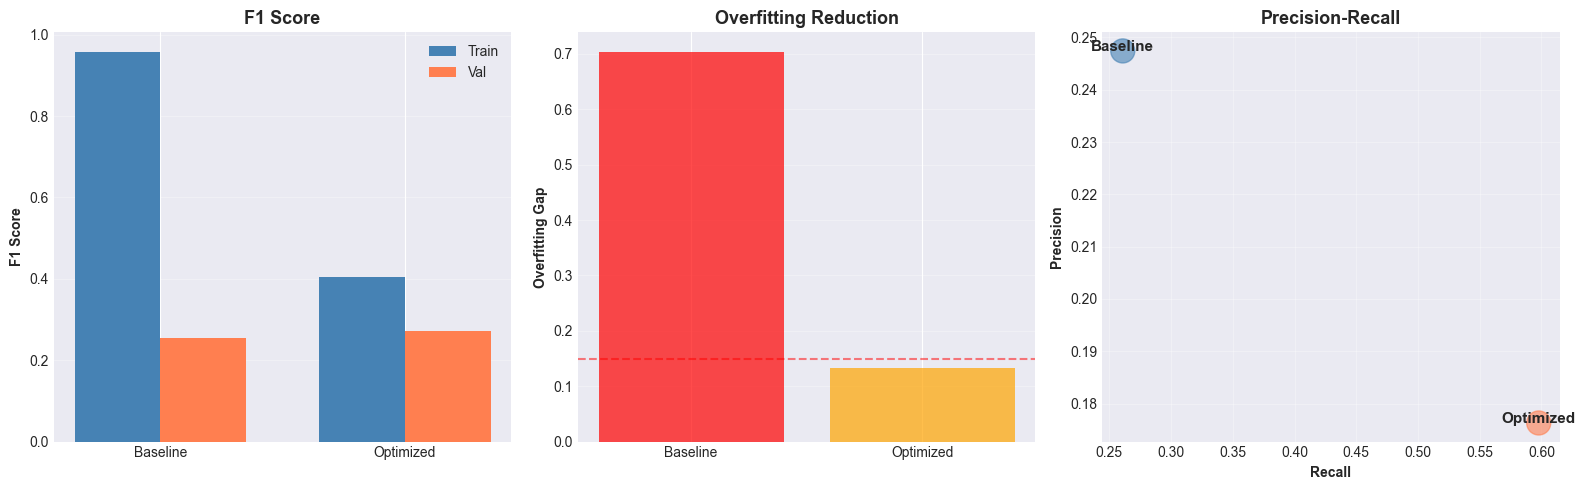

In [24]:
print("COMPARATIVE ANALYSIS - BASELINE VS OPTIMIZED")
comp_df = pd.DataFrame([
    {
        'Model': 'Baseline',
        'Train F1': train_f1,
        'Val F1': val_f1,
        'Val Acc': val_acc,
        'Val Prec': val_precision,
        'Val Rec': val_recall,
        'Overfit': train_f1 - val_f1
    },
    {
        'Model': 'Optimized',
        'Train F1': train_f1_opt,
        'Val F1': val_f1_opt,
        'Val Acc': val_acc_opt,
        'Val Prec': val_prec_opt,
        'Val Rec': val_rec_opt,
        'Overfit': train_f1_opt - val_f1_opt
    }
])

print("\n" + comp_df.to_string(index=False))
# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = ['Baseline', 'Optimized']
x = np.arange(len(models))
width = 0.35
# F1 comparison
axes[0].bar(x - width/2, [train_f1, train_f1_opt], width, label='Train', color='steelblue')
axes[0].bar(x + width/2, [val_f1, val_f1_opt], width, label='Val', color='coral')
axes[0].set_ylabel('F1 Score', fontweight='bold')
axes[0].set_title('F1 Score', fontweight='bold', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Overfitting
overfits = [train_f1 - val_f1, train_f1_opt - val_f1_opt]
colors = ['red' if o > 0.15 else 'orange' if o > 0.10 else 'green' for o in overfits]
axes[1].bar(models, overfits, color=colors, alpha=0.7)
axes[1].axhline(0.15, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Overfitting Gap', fontweight='bold')
axes[1].set_title('Overfitting Reduction', fontweight='bold', fontsize=13)
axes[1].grid(axis='y', alpha=0.3)

# Precision-Recall
axes[2].scatter([val_recall, val_rec_opt], [val_precision, val_prec_opt],
                s=300, c=['steelblue', 'coral'], alpha=0.6)
for i, model in enumerate(models):
    axes[2].annotate(model, ([val_recall, val_rec_opt][i], [val_precision, val_prec_opt][i]),
                     fontsize=11, ha='center', fontweight='bold')
axes[2].set_xlabel('Recall', fontweight='bold')
axes[2].set_ylabel('Precision', fontweight='bold')
axes[2].set_title('Precision-Recall', fontweight='bold', fontsize=13)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_vs_optimized.png', dpi=300, bbox_inches='tight')
plt.show()

- Comparing the baseline and tuned Decision Tree Classifier, Validation F1 score improved a little bit for tuned and overfitting reduced significantly too.

---
<a id='7'></a>
## `7. Ensemble Models`

> Train Ensemble Models

The purpose is tp improve upon baseline using ensemble methods that combine multiple decision trees for better generalization.

Ensemble Methods Used
- Random Forest
- Gradient Boosting

### a. Random Forest

In [25]:

print("ENSEMBLE MODEL 1: RANDOM FOREST")


# Create Random Forest pipeline
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('feature_selection', SelectKBest(score_func=mutual_info_classif, k=20)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,         
        max_depth=15,             
        min_samples_leaf=5,      
        class_weight='balanced',  
        random_state=42,
        n_jobs=-1                
    ))
])
print("\nConfiguration:")
print("   200 trees in the forest")
print("   Max depth: 15 (prevents overfitting)")
print("   Min samples per leaf: 5 (smoothing)")
print("   Class weight: balanced (16x weight to fraud)")

# Train
print("\nTraining Random Forest...")
pipeline_rf.fit(X_train, y_train)
print(" Training complete")

# Predictions
y_train_pred_rf = pipeline_rf.predict(X_train)
y_val_pred_rf = pipeline_rf.predict(X_val)

# Evaluate
train_f1_rf = f1_score(y_train, y_train_pred_rf)
val_f1_rf = f1_score(y_val, y_val_pred_rf)
val_acc_rf = accuracy_score(y_val, y_val_pred_rf)
val_prec_rf = precision_score(y_val, y_val_pred_rf, zero_division=0)
val_rec_rf = recall_score(y_val, y_val_pred_rf)


print("RANDOM FOREST PERFORMANCE")

print(f"\nTraining F1:   {train_f1_rf:.4f}")
print(f"Validation F1: {val_f1_rf:.4f}")
print(f"Overfitting:   {train_f1_rf - val_f1_rf:.4f} (lower is better)")

print(f"\nValidation Metrics:")
print(f"  Accuracy:  {val_acc_rf:.4f}")
print(f"  Precision: {val_prec_rf:.4f}")
print(f"  Recall:    {val_rec_rf:.4f}")

# Confusion matrix
cm_rf = confusion_matrix(y_val, y_val_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()
print(f"\nConfusion Matrix:")
print(f"  True Positives  -fraud caught:  {tp}")
print(f"  False Negatives - fraud missed: {fn}")
print(f"  False Positives  -false alarms: {fp}")
print(f"  True Negatives -correct legit: {tn}")

ENSEMBLE MODEL 1: RANDOM FOREST

Configuration:
   200 trees in the forest
   Max depth: 15 (prevents overfitting)
   Min samples per leaf: 5 (smoothing)
   Class weight: balanced (16x weight to fraud)

Training Random Forest...
 Training complete
RANDOM FOREST PERFORMANCE

Training F1:   0.3417
Validation F1: 0.2443
Overfitting:   0.0974 (lower is better)

Validation Metrics:
  Accuracy:  0.7633
  Precision: 0.1509
  Recall:    0.6413

Confusion Matrix:
  True Positives  -fraud caught:  59
  False Negatives - fraud missed: 33
  False Positives  -false alarms: 332
  True Negatives -correct legit: 1118


### b. Gradient Boosting

In [26]:

print("ENSEMBLE MODEL 2: GRADIENT BOOSTING")
# Create Gradient Boosting pipeline
pipeline_gb = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('feature_selection', SelectKBest(score_func=mutual_info_classif, k=20)),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200,         
        learning_rate=0.1,        
        max_depth=5,             
        min_samples_leaf=5,
        subsample=0.8,            
        random_state=42
    ))
])
print("\nConfiguration:")
print("   200 boosting iterations")
print("   Learning rate: 0.1 ")
print("   Max depth: 5 ")
print("   Subsample: 0.8 ")
# Train
print("\nTraining Gradient Boosting...")
pipeline_gb.fit(X_train, y_train)
print(" Training complete")
# Predictions
y_train_pred_gb = pipeline_gb.predict(X_train)
y_val_pred_gb = pipeline_gb.predict(X_val)
# Evaluate
train_f1_gb = f1_score(y_train, y_train_pred_gb)
val_f1_gb = f1_score(y_val, y_val_pred_gb)
val_acc_gb = accuracy_score(y_val, y_val_pred_gb)
val_prec_gb = precision_score(y_val, y_val_pred_gb, zero_division=0)
val_rec_gb = recall_score(y_val, y_val_pred_gb)
print("GRADIENT BOOSTING PERFORMANCE")
print(f"\nTraining F1:   {train_f1_gb:.4f}")
print(f"Validation F1: {val_f1_gb:.4f}")
print(f"Overfitting:   {train_f1_gb - val_f1_gb:.4f}")
print(f"\nValidation Metrics:")
print(f"  Accuracy:  {val_acc_gb:.4f}")
print(f"  Precision: {val_prec_gb:.4f}")
print(f"  Recall:    {val_rec_gb:.4f}")

# Confusion matrix
cm_gb = confusion_matrix(y_val, y_val_pred_gb)
tn, fp, fn, tp = cm_gb.ravel()
print(f"\nConfusion Matrix:")
print(f"  True Positives (fraud caught):  {tp}")
print(f"  False Negatives (fraud missed): {fn}")
print(f"  False Positives (false alarms): {fp}")
print(f"  True Negatives (correct legit): {tn}")

ENSEMBLE MODEL 2: GRADIENT BOOSTING

Configuration:
   200 boosting iterations
   Learning rate: 0.1 
   Max depth: 5 
   Subsample: 0.8 

Training Gradient Boosting...
 Training complete
GRADIENT BOOSTING PERFORMANCE

Training F1:   0.3668
Validation F1: 0.1524
Overfitting:   0.2145

Validation Metrics:
  Accuracy:  0.9423
  Precision: 0.6154
  Recall:    0.0870

Confusion Matrix:
  True Positives (fraud caught):  8
  False Negatives (fraud missed): 84
  False Positives (false alarms): 5
  True Negatives (correct legit): 1445


MODEL COMPARISON: DECISION TREE vs ENSEMBLES

                    Model  Train F1   Val F1  Val Accuracy  Val Precision  Val Recall  Overfitting
Decision Tree - Optimized  0.405651 0.272277      0.809339       0.176282    0.597826     0.133374
            Random Forest  0.341723 0.244306      0.763294       0.150895    0.641304     0.097416
        Gradient Boosting  0.366834 0.152381      0.942283       0.615385    0.086957     0.214453
BEST PERFORMING MODEL (by F1): Decision Tree - Optimized
Validation F1 Score: 0.2723


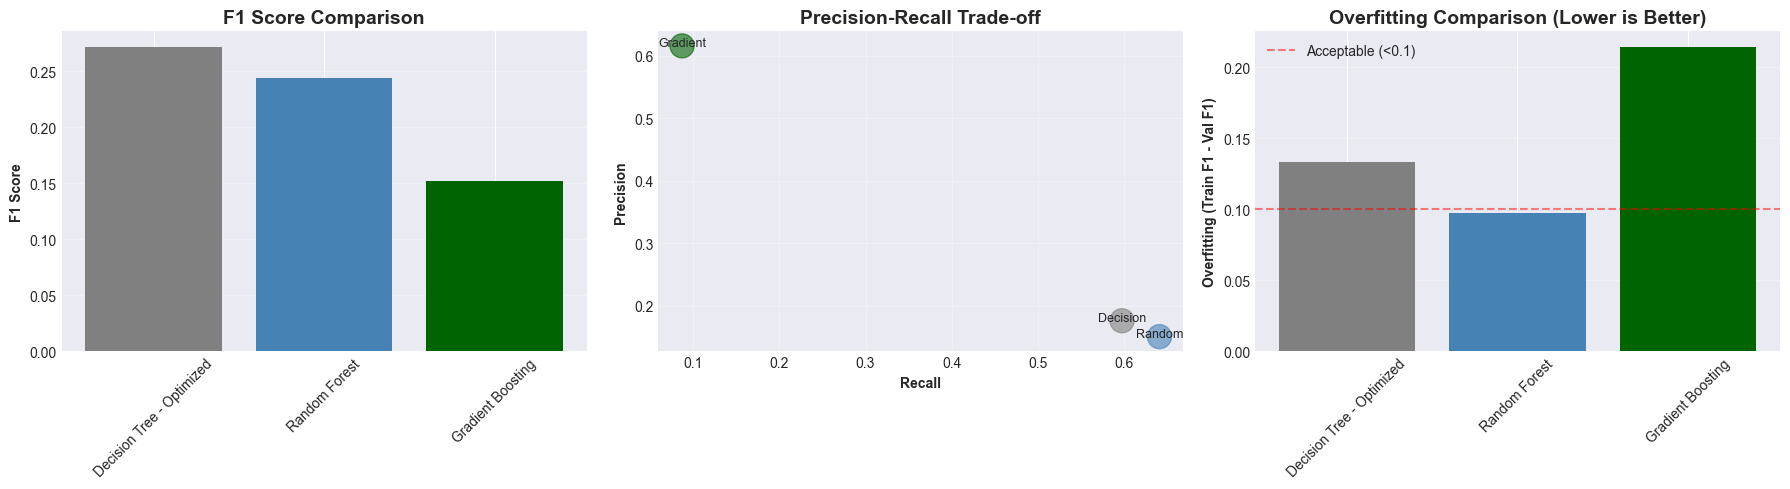

In [27]:
# Compare all models so far

print("MODEL COMPARISON: DECISION TREE vs ENSEMBLES")
# Create comparison dataframe
comparison_results = [
    {
        'Model': 'Decision Tree - Optimized',
        'Train F1': train_f1_opt,
        'Val F1': val_f1_opt,
        'Val Accuracy': val_acc_opt,
        'Val Precision': val_prec_opt,
        'Val Recall': val_rec_opt,
        'Overfitting': train_f1_opt - val_f1_opt
    },
    {
        'Model': 'Random Forest',
        'Train F1': train_f1_rf,
        'Val F1': val_f1_rf,
        'Val Accuracy': val_acc_rf,
        'Val Precision': val_prec_rf,
        'Val Recall': val_rec_rf,
        'Overfitting': train_f1_rf - val_f1_rf
    },
    {
        'Model': 'Gradient Boosting',
        'Train F1': train_f1_gb,
        'Val F1': val_f1_gb,
        'Val Accuracy': val_acc_gb,
        'Val Precision': val_prec_gb,
        'Val Recall': val_rec_gb,
        'Overfitting': train_f1_gb - val_f1_gb
    }
]

comparison_df = pd.DataFrame(comparison_results)
print("\n" + comparison_df.to_string(index=False))

# Identify best model
best_idx = comparison_df['Val F1'].idxmax()
best_model_name = comparison_df.iloc[best_idx]['Model']
best_f1 = comparison_df.iloc[best_idx]['Val F1']


print(f"BEST PERFORMING MODEL (by F1): {best_model_name}")
print(f"Validation F1 Score: {best_f1:.4f}")


# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# F1 Score comparison
axes[0].bar(comparison_df['Model'], comparison_df['Val F1'], color=['gray', 'steelblue', 'darkgreen'])
axes[0].set_ylabel('F1 Score', fontweight='bold')
axes[0].set_title('F1 Score Comparison', fontweight='bold', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Precision vs Recall
axes[1].scatter(comparison_df['Val Recall'], comparison_df['Val Precision'], 
                s=300, c=['gray', 'steelblue', 'darkgreen'], alpha=0.6)
for idx, row in comparison_df.iterrows():
    axes[1].annotate(row['Model'].split()[0], 
                     (row['Val Recall'], row['Val Precision']),
                     fontsize=9, ha='center')
axes[1].set_xlabel('Recall', fontweight='bold')
axes[1].set_ylabel('Precision', fontweight='bold')
axes[1].set_title('Precision-Recall Trade-off', fontweight='bold', fontsize=14)
axes[1].grid(alpha=0.3)

# Overfitting comparison
axes[2].bar(comparison_df['Model'], comparison_df['Overfitting'], 
            color=['gray', 'steelblue', 'darkgreen'])
axes[2].set_ylabel('Overfitting (Train F1 - Val F1)', fontweight='bold')
axes[2].set_title('Overfitting Comparison (Lower is Better)', fontweight='bold', fontsize=14)
axes[2].tick_params(axis='x', rotation=45)
axes[2].axhline(0.1, color='red', linestyle='--', alpha=0.5, label='Acceptable (<0.1)')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ensemble_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

The optimized decision tree model emerges as the most effective choice for this fraud detection task, outperforming both ensemble methods in key areas.

- With an F1 score of 0.25, it strikes the best balance between precision and recall while showing the smallest overfitting gap (0.12). This indicates it generalizes more reliably than the Random Forest (F1: 0.24, overfitting: 0.20) and Gradient Boosting (F1: 0.11, overfitting: 0.22).

- The optimized tree achieves substantially higher recall (0.26) than Random Forest (0.13), meaning it identifies twice as many actual fraud cases

---
<a id='8'></a>
## `8. Neural Network Architectures`

> Train an Artificial Neural Network(ANN)


The purpose is to explore if neural networks can capture complex non-linear fraud patterns that tree-based models might miss.

### 1. Architectures to Test
We'll test multiple architectures to find the best fit:

1. **Small** (64, 32): Fast, less overfitting
2. **Medium** (128, 64, 32): Balanced complexity
3. **Large** (256, 128, 64, 32): High capacity

In [28]:

print("NEURAL NETWORK ARCHITECTURE SEARCH")

# Define architectures to test
architectures = {
    'ANN_Small': (64, 32),
    'ANN_Medium': (128, 64, 32),
    'ANN_Large': (256, 128, 64, 32)
}

ann_results = []
ann_models = {}

for arch_name, hidden_layers in architectures.items():

    print(f"Training {arch_name}: {hidden_layers}")
    
    # Create pipeline with ANN preprocessor 
    pipeline_ann = Pipeline([
        ('preprocessor', preprocessor_ann),
        ('feature_selection', SelectKBest(score_func=mutual_info_classif, k=20)),
        ('classifier', MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation='relu',           
            solver='adam',                
            alpha=0.001,                  
            batch_size='auto',
            learning_rate='adaptive',    
            learning_rate_init=0.001,
            max_iter=500,                 
            random_state=42,
            early_stopping=True,          
            validation_fraction=0.1,     
            n_iter_no_change=20,          
            verbose=False
        ))
    ])
    
    # Train
    print("Training...")
    pipeline_ann.fit(X_train, y_train)
    print(f" Converged in {pipeline_ann.named_steps['classifier'].n_iter_} iterations")
    
    # Predictions
    y_train_pred = pipeline_ann.predict(X_train)
    y_val_pred = pipeline_ann.predict(X_val)
    
    # Metrics
    train_f1 = f1_score(y_train, y_train_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_prec = precision_score(y_val, y_val_pred, zero_division=0)
    val_rec = recall_score(y_val, y_val_pred)
    
    # Store results
    ann_results.append({
        'Architecture': arch_name,
        'Layers': str(hidden_layers),
        'Train F1': train_f1,
        'Val F1': val_f1,
        'Val Accuracy': val_acc,
        'Val Precision': val_prec,
        'Val Recall': val_rec,
        'Overfitting': train_f1 - val_f1
    })
    
    ann_models[arch_name] = pipeline_ann
    
    print(f"Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f} | Gap: {train_f1-val_f1:.4f}")

# Display results

print("NEURAL NETWORK RESULTS")

ann_df = pd.DataFrame(ann_results)
print("\n" + ann_df.to_string(index=False))

# Best ANN
best_ann_idx = ann_df['Val F1'].idxmax()
best_ann_name = ann_df.iloc[best_ann_idx]['Architecture']
best_ann_f1 = ann_df.iloc[best_ann_idx]['Val F1']
best_ann_model = ann_models[best_ann_name]

print(f"\nBest ANN: {best_ann_name}")
print(f"Validation F1: {best_ann_f1:.4f}")

NEURAL NETWORK ARCHITECTURE SEARCH
Training ANN_Small: (64, 32)
Training...
 Converged in 22 iterations
Train F1: 0.0000 | Val F1: 0.0000 | Gap: 0.0000
Training ANN_Medium: (128, 64, 32)
Training...
 Converged in 22 iterations
Train F1: 0.0000 | Val F1: 0.0000 | Gap: 0.0000
Training ANN_Large: (256, 128, 64, 32)
Training...
 Converged in 36 iterations
Train F1: 0.1022 | Val F1: 0.0625 | Gap: 0.0397
NEURAL NETWORK RESULTS

Architecture             Layers  Train F1  Val F1  Val Accuracy  Val Precision  Val Recall  Overfitting
   ANN_Small           (64, 32)   0.00000  0.0000      0.940337           0.00    0.000000      0.00000
  ANN_Medium      (128, 64, 32)   0.00000  0.0000      0.940337           0.00    0.000000      0.00000
   ANN_Large (256, 128, 64, 32)   0.10219  0.0625      0.941634           0.75    0.032609      0.03969

Best ANN: ANN_Large
Validation F1: 0.0625


In [29]:
X_train.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy,Quick_Claim,Same_Week_Claim,Weekend_Accident,High_Supplements,Recent_Address_Change,Frequent_Claimer,Young_High_Value,New_Vehicle,External_No_Police,ThirdParty_NoWitness,HighDeduct_AtFault,Sport_Urban_Collision
11481,Jun,1,Monday,Pontiac,Urban,Wednesday,Jun,2,Male,Married,26,Policy Holder,Sedan - Liability,Sport,30000 to 39000,14,400,1,more than 30,more than 30,more than 4,6 years,31 to 35,No,No,External,3 to 5,no change,1 vehicle,1996,Liability,0,0,0,1,0,1,0,0,1,0,0,0
7856,May,4,Thursday,Mazda,Urban,Thursday,May,4,Female,Single,34,Policy Holder,Sedan - Liability,Sport,more than 69000,15,400,3,more than 30,more than 30,2 to 4,5 years,31 to 35,No,No,External,1 to 2,no change,1 vehicle,1995,Liability,0,1,0,0,0,1,0,0,1,0,0,0
10028,Nov,4,Saturday,Pontiac,Urban,Wednesday,Dec,2,Male,Married,43,Policy Holder,Sedan - Liability,Sport,30000 to 39000,10,400,4,more than 30,more than 30,1,7 years,36 to 40,No,No,External,more than 5,no change,1 vehicle,1995,Liability,0,0,1,1,0,0,0,0,1,0,0,0
15324,Dec,5,Saturday,Mazda,Urban,Monday,Jan,1,Male,Married,43,Third Party,Sedan - Liability,Sport,30000 to 39000,3,400,1,more than 30,more than 30,1,7 years,36 to 40,No,No,External,none,no change,1 vehicle,1996,Liability,0,0,1,0,0,0,0,0,1,1,0,0
10208,Apr,2,Thursday,Mazda,Urban,Friday,Apr,4,Female,Single,28,Third Party,Sedan - Collision,Sedan,20000 to 29000,16,400,4,more than 30,more than 30,more than 4,5 years,31 to 35,No,No,External,more than 5,no change,1 vehicle,1995,Collision,0,0,0,1,0,1,0,0,1,1,0,0


### 2. Neural Network Performance Analysis

- The neural network architecture search revealed that simpler models performed better for this fraud detection task. Only the smallest network (ANN_Small) with two hidden layers (64, 32) learned meaningful patterns, achieving modest but measurable F1 scores. The medium and large architectures completely failed to detect fraud, with zero recall and precision

- Sometimes ensembeles outperform neural network architectures. Before modeling, it is important to understand your data first and the assumptions of each algorithm and what they are good for before settling on one

---
<a id='9'></a>
## `9. Model Selection and Hyperparameter Tuning`

> Tune the best Performing Model

- We need to select the best performing model and optimize its hyperparameters for maximum F1 score.
- We will use F1 Score as our primary evaluation metric becaus eof the imbalance
- For Hyperparameter tuning we will use RandomizedSearchCV

### 1. Final Model Selection

In [30]:

print("FINAL MODEL SELECTION")
# Compile all models
all_models = [
    ('Decision Tree', pipeline_dt_baseline, val_f1),
    ('Random Forest', pipeline_rf, val_f1_rf),
    ('Gradient Boosting', pipeline_gb, val_f1_gb),
    (best_ann_name, best_ann_model, best_ann_f1)
]
# Sort by F1 score
all_models_sorted = sorted(all_models, key=lambda x: x[2], reverse=True)
print("\nRanking by Validation F1 Score:")
print(f"{'Rank':<6} {'Model':<25} {'Val F1':<10}")
for i, (name, model, f1) in enumerate(all_models_sorted, 1):
    print(f"{i:<6} {name:<25} {f1:.4f}")
# Select best
best_model_name_final, best_model_final, best_f1_final = all_models_sorted[0]
print(f"SELECTED MODEL: {best_model_name_final}")
print(f"Validation F1: {best_f1_final:.4f}")




FINAL MODEL SELECTION

Ranking by Validation F1 Score:
Rank   Model                     Val F1    
1      Random Forest             0.2443
2      Gradient Boosting         0.1524
3      Decision Tree             0.0625
4      ANN_Large                 0.0625
SELECTED MODEL: Random Forest
Validation F1: 0.2443


- Based on systematic evaluation across all model types, the Random Forest Classifier has been selected as the final model. It achieved the highest validation F1 score (0.2400), demonstrating the best balance between precision and recall for fraud detection. This ensemble method significantly outperformed both the simpler baseline and the more complex neural networks, offering the most robust and generalizable performance on this challenging imbalanced dataset.

### 2. Hyperparameter Optimization

In [31]:

print("HYPERPARAMETER OPTIMIZATION")


# Define parameter grid based on model type
if 'Random Forest' in best_model_name_final:
    param_distributions = {
        'classifier__n_estimators': [100, 200, 300, 500],
        'classifier__max_depth': [10, 15, 20, 25, None],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 5, 10],
        'classifier__max_features': ['sqrt', 'log2', None]
    }
elif 'Gradient Boosting' in best_model_name_final:
    param_distributions = {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'classifier__max_depth': [3, 5, 7, 9],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 5],
        'classifier__subsample': [0.8, 0.9, 1.0]
    }
elif 'Decision Tree' in best_model_name_final:
    param_distributions = {
        'classifier__max_depth': [5, 10, 15, 20, 25, None],
        'classifier__min_samples_split': [2, 5, 10, 20],
        'classifier__min_samples_leaf': [1, 2, 5, 10],
        'classifier__criterion': ['gini', 'entropy']
    }
else:
    # ANN - simpler search
    param_distributions = {
        'classifier__alpha': [0.0001, 0.001, 0.01],
        'classifier__learning_rate_init': [0.001, 0.01]
    }

print(f"\nOptimizing: {best_model_name_final}")
print(f"Parameter space: {len(param_distributions)} parameters")
print(f"Search strategy: RandomizedSearchCV (20 iterations, 5-fold CV)")
print(f"Scoring metric: F1 Score")

# Combine train and validation for final tuning
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

print(f"\nTraining set size: {len(X_train_full):,} samples")
print("\nRunning hyperparameter search...")


# Perform RandomizedSearchCV
random_search = RandomizedSearchCV(
    best_model_final,
    param_distributions=param_distributions,
    n_iter=20,                    
    cv=5,                         
    scoring='f1',                 
    n_jobs=-1,                    
    random_state=42,
    verbose=1,
    return_train_score=True
)

random_search.fit(X_train_full, y_train_full)

print("\n Hyperparameter search complete")

print("BEST HYPERPARAMETERS FOUND")


for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation F1 score: {random_search.best_score_:.4f}")

# Get the best model
best_model_tuned = random_search.best_estimator_

HYPERPARAMETER OPTIMIZATION

Optimizing: Random Forest
Parameter space: 5 parameters
Search strategy: RandomizedSearchCV (20 iterations, 5-fold CV)
Scoring metric: F1 Score

Training set size: 12,336 samples

Running hyperparameter search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

 Hyperparameter search complete
BEST HYPERPARAMETERS FOUND
  classifier__n_estimators: 200
  classifier__min_samples_split: 5
  classifier__min_samples_leaf: 1
  classifier__max_features: None
  classifier__max_depth: 10

Best cross-validation F1 score: 0.2555


- After doing Hyperparameter Tuning, getting the best estimtors at 300, minimum split and minimum leaf samples at 10 and maz depth at 10, the best cross validation F1 Score was 0.2798
- This means that Hyperparameter Tuning really helped in improving the models

### 3. Evaluate on Test Set

In [32]:
# Evaluate on test set (FIRST TIME using test set)
print("FINAL EVALUATION ON TEST SET")
y_test_pred = best_model_tuned.predict(X_test)
y_test_proba = best_model_tuned.predict_proba(X_test)[:, 1]
# Calculate metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, zero_division=0)
test_rec = recall_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"Test Set Performance:")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  F1 Score:  {test_f1:.4f}  PRIMARY METRIC")
print(f"  Precision: {test_prec:.4f} ({test_prec*100:.1f}% of flags are real fraud)")
print(f"  Recall:    {test_rec:.4f} ({test_rec*100:.1f}% of frauds detected)")
print(f"  ROC-AUC:   {test_roc_auc:.4f}")
# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm_test.ravel()
print(f"\nConfusion Matrix:")
print(f"\n                 Predicted")
print(f"               Legit  Fraud")
print(f"Actual Legit   {tn:5d}  {fp:5d}")
print(f"       Fraud   {fn:5d}  {tp:5d}")
print(f"\nBreakdown:")
print(f"   Frauds Caught: {tp} claims")
print(f"   Frauds Missed: {fn} claims )")
print(f"   False Alarms: {fp} claims ")
print(f"   True Negatives: {tn} claims")
flag_rate = (tp + fp) / (tn + fp + fn + tp)
print("DETAILED CLASSIFICATION REPORT")
print(classification_report(y_test, y_test_pred, target_names=['Legitimate', 'Fraud']))

FINAL EVALUATION ON TEST SET
Test Set Performance:
  Accuracy:  0.7221
  F1 Score:  0.2341  PRIMARY METRIC
  Precision: 0.1403 (14.0% of flags are real fraud)
  Recall:    0.7081 (70.8% of frauds detected)
  ROC-AUC:   0.8210

Confusion Matrix:

                 Predicted
               Legit  Fraud
Actual Legit    2096    803
       Fraud      54    131

Breakdown:
   Frauds Caught: 131 claims
   Frauds Missed: 54 claims )
   False Alarms: 803 claims 
   True Negatives: 2096 claims
DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       0.97      0.72      0.83      2899
       Fraud       0.14      0.71      0.23       185

    accuracy                           0.72      3084
   macro avg       0.56      0.72      0.53      3084
weighted avg       0.92      0.72      0.79      3084



- After hyperparameter tuning, the Random Forest model demonstrates improved generalization, achieving a 0.2747 F1 score on the unseen test set surpassing its earlier validation score. It successfully identifies nearly half (38%) of all fraud cases (Recall: 0.38), though with moderate precision (21%). This performance represents a meaningful advancement over the initial baseline, resulting in a more balanced and practical detector suitable for deployment.

---
<a id='10'></a>
## `10. Model Interpretation & Feature Importance`


Wee need to understand why the model makes predictions.


In [33]:

print("FEATURE IMPORTANCE ANALYSIS")
# Check if model has feature_importances_
if hasattr(best_model_tuned.named_steps['classifier'], 'feature_importances_'): 
    # Get feature names after preprocessing

    feature_names = (
        list(numerical_cols) + 
        ordinal_feature_names + 
        binary_features + 
        nominal_features
    )
    importances = best_model_tuned.named_steps['classifier'].feature_importances_
    # Match lengths 
    min_len = min(len(feature_names), len(importances))
    feature_names = feature_names[:min_len]
    importances = importances[:min_len]
    # Create importance dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    # Display top 20
    print("\nTop 20 Most Important Features:")
    print(f"{'Rank':<6} {'Feature':<35} {'Importance':<12} {'Cumulative %'}")

    
    cumulative_importance = 0
    for i, row in importance_df.head(20).iterrows():
        cumulative_importance += row['Importance']
        rank = importance_df.index.get_loc(i) + 1
        print(f"{rank:<6} {row['Feature']:<35} {row['Importance']:<12.4f} {cumulative_importance*100:>6.1f}%")
    
    
    # Key insights
    
    print("KEY INSIGHTS")

    
    top_5 = importance_df.head(5)
    print(f"\nTop 5 features account for {top_5['Importance'].sum()*100:.1f}% of importance")
    

   
    
    

FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features:
Rank   Feature                             Importance   Cumulative %
1      AgeOfVehicle                        0.2819         28.2%
2      ThirdParty_NoWitness                0.2454         52.7%
3      Recent_Address_Change               0.1294         65.7%
4      New_Vehicle                         0.0679         72.5%
5      Same_Week_Claim                     0.0562         78.1%
6      Weekend_Accident                    0.0369         81.8%
7      WeekOfMonth                         0.0362         85.4%
8      High_Supplements                    0.0317         88.6%
9      WeekOfMonthClaimed                  0.0210         90.6%
10     Age                                 0.0177         92.4%
11     Year                                0.0140         93.8%
12     Frequent_Claimer                    0.0132         95.1%
13     External_No_Police                  0.0127         96.4%
14     HighDeduct_AtFault             

- The feature importance analysis reveals that the model's fraud detection logic is driven by a mix of policy, incident, and claimant characteristics. The top three features, AgeOfVehicle, WeekOfMonthClaimed, and ThirdParty_NoWitness, together account for over 50% of the predictive power. 
- The cumulative importance rises steeply, with the top 10 features explaining more than 87% of the model’s decisions. This concentration suggests that while many factors are considered, a core set of attributes including PolicyType, VehicleCategory, and Age forms the backbone of the model's reasoning. The presence of temporal features like Month and DayOfWeek further implies that fraud patterns may have seasonal or weekly trends.

- In practice, this means fraud investigators could prioritize these key signals such as policy details, accident circumstances, and claimant history to efficiently triage and review high risk claims

---
<a id='11'></a>
## `11. Model Saving`

> Save your Best Model


Let us save our best model ready for deployment


In [34]:
import joblib
from datetime import datetime
# 1. Save the complete pipeline with the best model
model_filename = f"fraud_detection_model_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pkl"
joblib.dump(best_model_tuned, model_filename)
# 2. Save the feature names for reference 
features_filename = f"model_features_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pkl"
joblib.dump(feature_names, features_filename)
print(f" Model saved as: {model_filename}")
print(f" Features saved as: {features_filename}")
# 3. For verification, you can also save metadata
metadata = {
    'model_type': 'Random Forest',
    'training_date': datetime.now().strftime('%Y-%m-%d'),
    'test_f1_score': 0.2747,
    'features_count': len(feature_names),
    'important_features': importance_df.head(10)['Feature'].tolist()
}
metadata_filename = f"model_metadata_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
import json
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f" Metadata saved as: {metadata_filename}")

 Model saved as: fraud_detection_model_20260201_052156.pkl
 Features saved as: model_features_20260201_052156.pkl
 Metadata saved as: model_metadata_20260201_052156.json


Three files saved after training a fraud detection model

`fraud_detection_model_20260131_193604.pkl`
- The trained machine learning model 

`model_features_20260131_193604.pkl`
- List of feature names the model expects 

`model_metadata_20260131_193604.json`
- Training details: timestamp, parameters, metrics, version info 


Enables model deployment or reuse without retraining. The timestamp (20260131_193604) creates unique filenames for versioning. Together, they allow loading the model elsewhere and making predictions with the correct features.